In [161]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [106]:
data = pd.read_csv("D:/cursos/curso-machine-learning/bases_dados/parkinsons_updrs.csv")
data

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5870,42,61,0,142.7900,22.485,33.485,0.00406,0.000031,0.00167,0.00168,...,0.160,0.00973,0.01133,0.01549,0.02920,0.025137,22.369,0.64215,0.55314,0.21367
5871,42,61,0,149.8400,21.988,32.988,0.00297,0.000025,0.00119,0.00147,...,0.215,0.01052,0.01277,0.01904,0.03157,0.011927,22.886,0.52598,0.56518,0.12621
5872,42,61,0,156.8200,21.495,32.495,0.00349,0.000025,0.00152,0.00187,...,0.244,0.01371,0.01456,0.01877,0.04112,0.017701,25.065,0.47792,0.57888,0.14157
5873,42,61,0,163.7300,21.007,32.007,0.00281,0.000020,0.00128,0.00151,...,0.131,0.00693,0.00870,0.01307,0.02078,0.007984,24.422,0.56865,0.56327,0.14204


In [107]:
data.loc[:, "sex"] = data["sex"].map({0: 'male', 1: 'female'})

C:\Users\Fern4\AppData\Local\Temp\ipykernel_10816\648068690.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['male' 'male' 'male' ... 'male' 'male' 'male']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, "sex"] = data["sex"].map({0: 'male', 1: 'female'})


In [108]:
(data["sex"] == "male").sum(), (data["sex"] == "female").sum()

(np.int64(4008), np.int64(1867))

In [109]:
np.unique(data["sex"], return_counts=True)

(array(['female', 'male'], dtype=object), array([1867, 4008]))

In [110]:
data.isnull().sum()

subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64

In [111]:
data.describe()

,subject#,age,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,0.008962,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,0.009371,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,0.000980,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,0.004730,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,0.006750,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,0.009870,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,0.172630,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


In [112]:
data.corr(numeric_only=True)

,subject#,age,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
subject#,1.000000,-0.030864,-0.000882,0.252919,0.253643,0.135448,0.075156,0.120339,0.136474,0.120350,...,0.142864,0.112950,0.138264,0.173333,0.112949,0.168743,-0.206929,0.147300,0.097464,0.157559
age,-0.030864,1.000000,0.019884,0.273665,0.310290,0.023071,0.035691,0.010255,0.013199,0.010258,...,0.111130,0.098912,0.089983,0.135238,0.098913,0.007093,-0.104842,0.090208,-0.092870,0.120790
test_time,-0.000882,0.019884,1.000000,0.067918,0.075263,-0.022837,-0.011365,-0.028888,-0.023290,-0.028876,...,-0.030962,-0.029020,-0.036504,-0.039110,-0.029017,-0.026357,0.036545,-0.038887,0.019261,-0.000563
motor_UPDRS,0.252919,0.273665,0.067918,1.000000,0.947231,0.084816,0.050903,0.072684,0.076291,0.072698,...,0.110076,0.084261,0.092105,0.136560,0.084260,0.074967,-0.157029,0.128607,-0.116242,0.162433
total_UPDRS,0.253643,0.310290,0.075263,0.947231,1.000000,0.074247,0.066927,0.064015,0.063352,0.064027,...,0.098790,0.079363,0.083467,0.120838,0.079363,0.060952,-0.162117,0.156897,-0.113475,0.156195
Jitter(%),0.135448,0.023071,-0.022837,0.084816,0.074247,1.000000,0.865577,0.984181,0.968214,0.984184,...,0.716704,0.664149,0.694002,0.645965,0.664147,0.825294,-0.675188,0.427128,0.226550,0.721849
Jitter(Abs),0.075156,0.035691,-0.011365,0.050903,0.066927,0.865577,1.000000,0.844626,0.790538,0.844630,...,0.655871,0.623830,0.621401,0.589998,0.623827,0.699960,-0.706418,0.547100,0.352264,0.787853
Jitter:RAP,0.120339,0.010255,-0.028888,0.072684,0.064015,0.984181,0.844626,1.000000,0.947196,1.000000,...,0.685551,0.650226,0.659831,0.603082,0.650225,0.792373,-0.641473,0.382891,0.214881,0.670652
Jitter:PPQ5,0.136474,0.013199,-0.023290,0.076291,0.063352,0.968214,0.790538,0.947196,1.000000,0.947203,...,0.734591,0.676711,0.734021,0.668413,0.676710,0.864864,-0.662409,0.381503,0.175359,0.663491
Jitter:DDP,0.120350,0.010258,-0.028876,0.072698,0.064027,0.984184,0.844630,1.000000,0.947203,1.000000,...,0.685556,0.650228,0.659833,0.603090,0.650227,0.792377,-0.641482,0.382886,0.214893,0.670660


<Axes: >

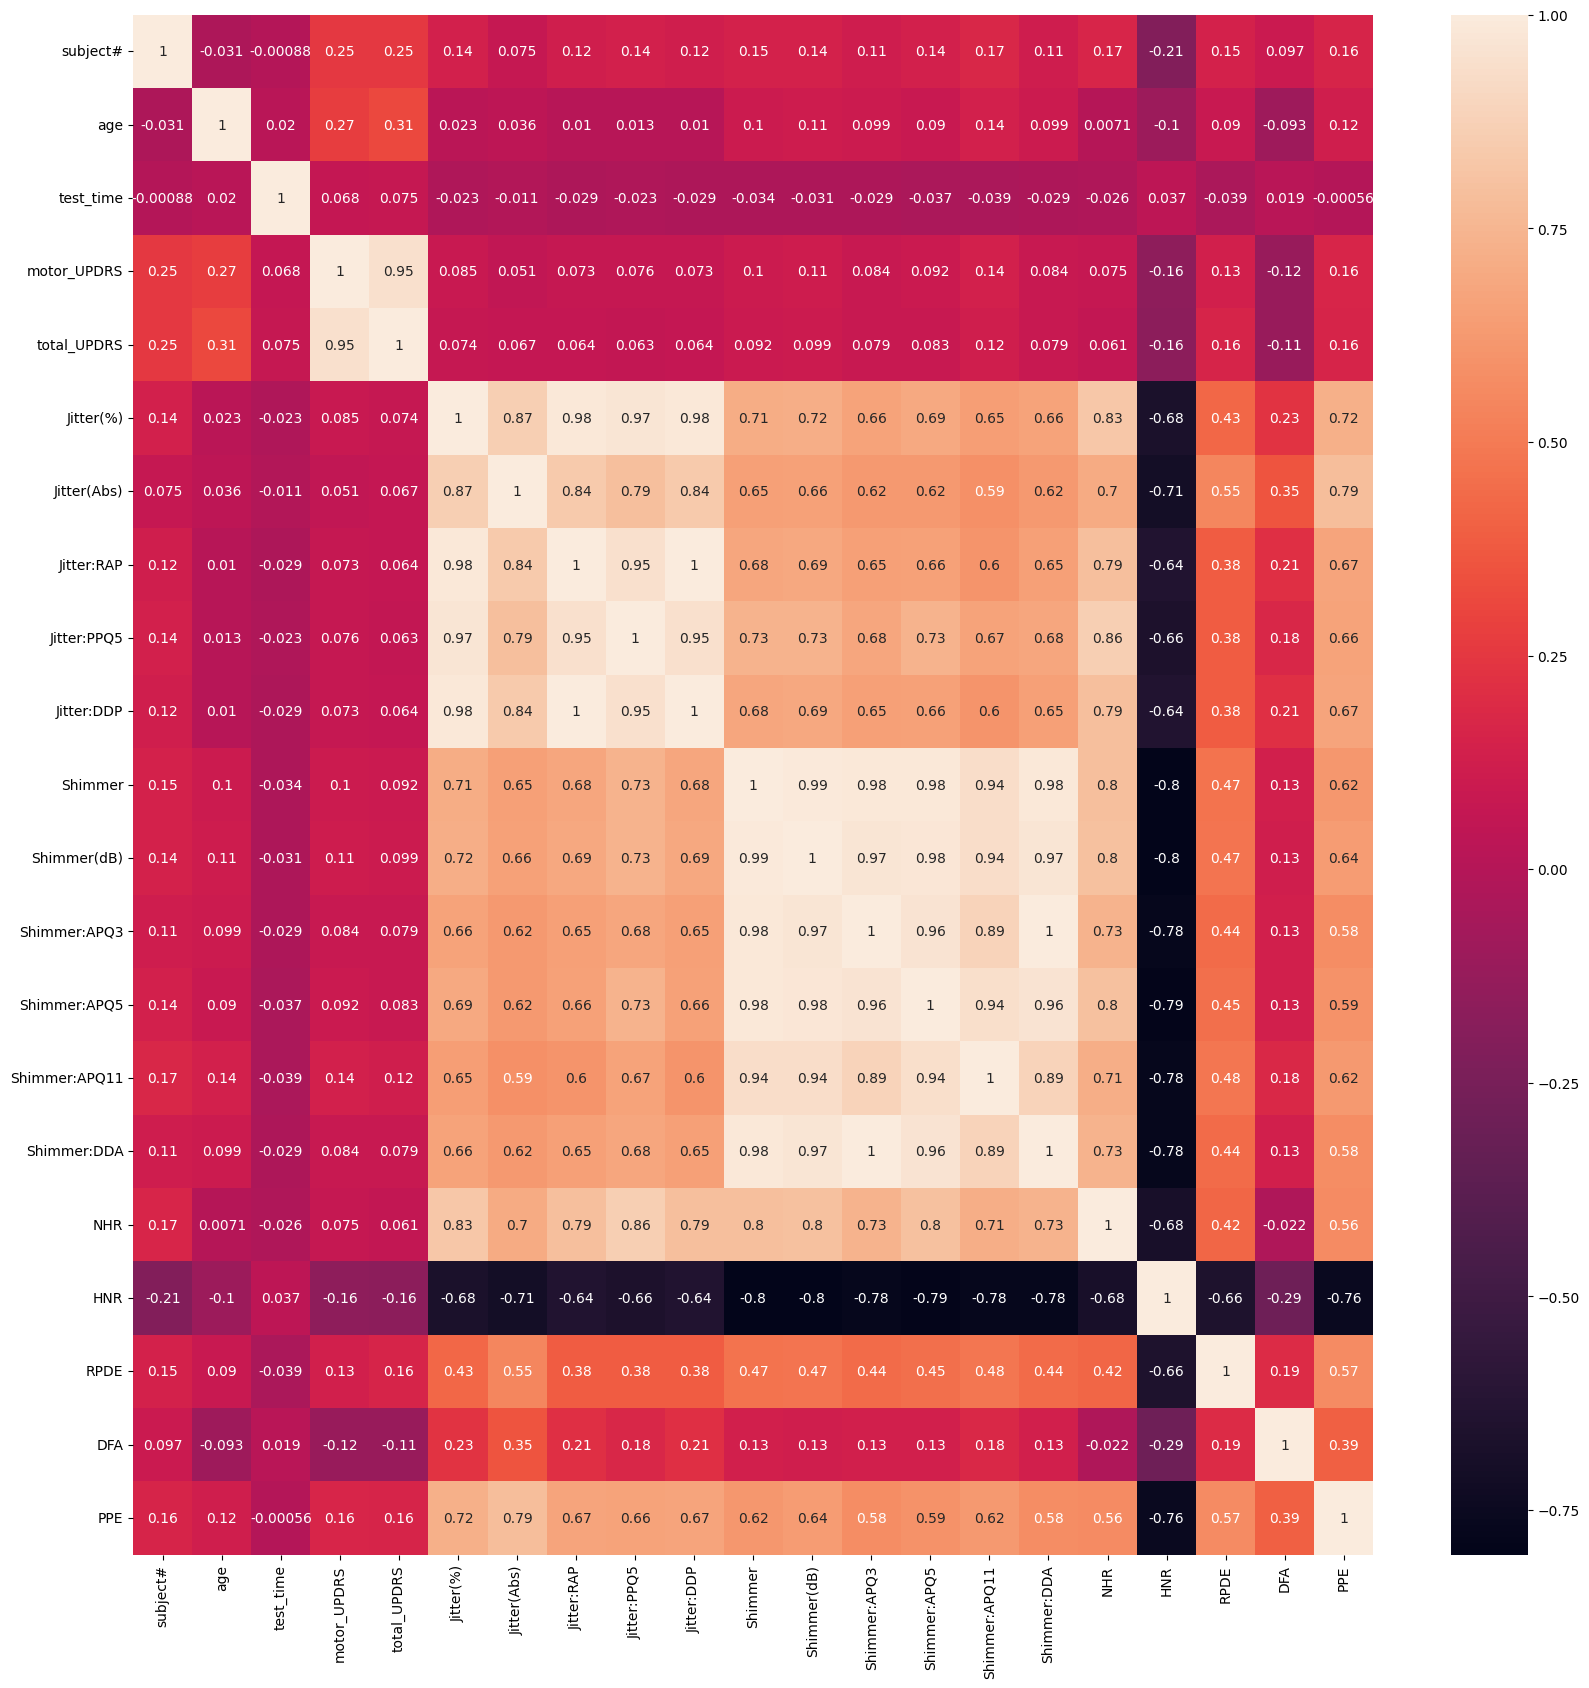

In [113]:
fig = plt.figure(figsize=(20,20))
sns.heatmap(data.corr(numeric_only=True), annot=True)

In [114]:
data.loc[:, "sex"] = data["sex"].map({"male": 0, "female": 1})

In [115]:
data.isnull().sum()

subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64

In [116]:
y = data.iloc[:,4:6].values
y

array([[28.199, 34.398],
       [28.447, 34.894],
       [28.695, 35.389],
       ...,
       [21.495, 32.495],
       [21.007, 32.007],
       [20.513, 31.513]], shape=(5875, 2))

In [117]:
x = data.iloc[:, np.r_[0:4, 6:22]].values
x

array([[1, 72, 0, ..., 0.41888, 0.54842, 0.16006],
       [1, 72, 0, ..., 0.43493, 0.56477, 0.1081],
       [1, 72, 0, ..., 0.46222, 0.54405, 0.21014],
       ...,
       [42, 61, 0, ..., 0.47792, 0.57888, 0.14157],
       [42, 61, 0, ..., 0.56865, 0.56327, 0.14204],
       [42, 61, 0, ..., 0.58608, 0.57077, 0.15336]],
      shape=(5875, 20), dtype=object)

In [118]:
#data = data.drop('motor_UPDRS', axis=1)
#data = data.drop('total_UPDRS', axis=1)


In [119]:
#data

In [123]:
from sklearn.model_selection import train_test_split

In [135]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

In [131]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [136]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [137]:
lr.intercept_

array([27.2462657 , 35.39378256])

In [139]:
lr.coef_

array([[ 1.72471289e-01,  1.99092309e-01, -2.44610755e+00,
         1.33645929e-02,  1.61438815e+02, -5.08113926e+04,
        -4.64799378e+04, -3.07934017e+02,  1.56906758e+04,
         6.15637671e+01,  4.34136367e-01, -2.45318860e+03,
        -3.57158735e+01,  4.15943753e+01,  7.64443497e+02,
        -2.06151991e+01, -3.28338058e-01, -9.16498010e-02,
        -2.75718037e+01,  1.54259385e+01],
       [ 2.56966764e-01,  3.16838559e-01, -4.77699105e+00,
         1.89694793e-02, -2.63606240e+02, -4.13361959e+04,
        -5.27276105e+04, -2.62153411e+02,  1.80025535e+04,
         5.13308991e+00,  3.14080280e+00, -9.35447948e+03,
         8.61236243e+01,  4.63417821e+00,  3.04492489e+03,
        -2.96399926e+01, -4.85605873e-01,  2.42580722e+00,
        -3.77858474e+01,  1.54078300e+01]])

In [145]:
lr.score(x_train, y_train)

0.23809844389038753

In [146]:
lr.score(x_test, y_test)

0.22383228838414188

In [147]:
previsoes = lr.predict(x_test)

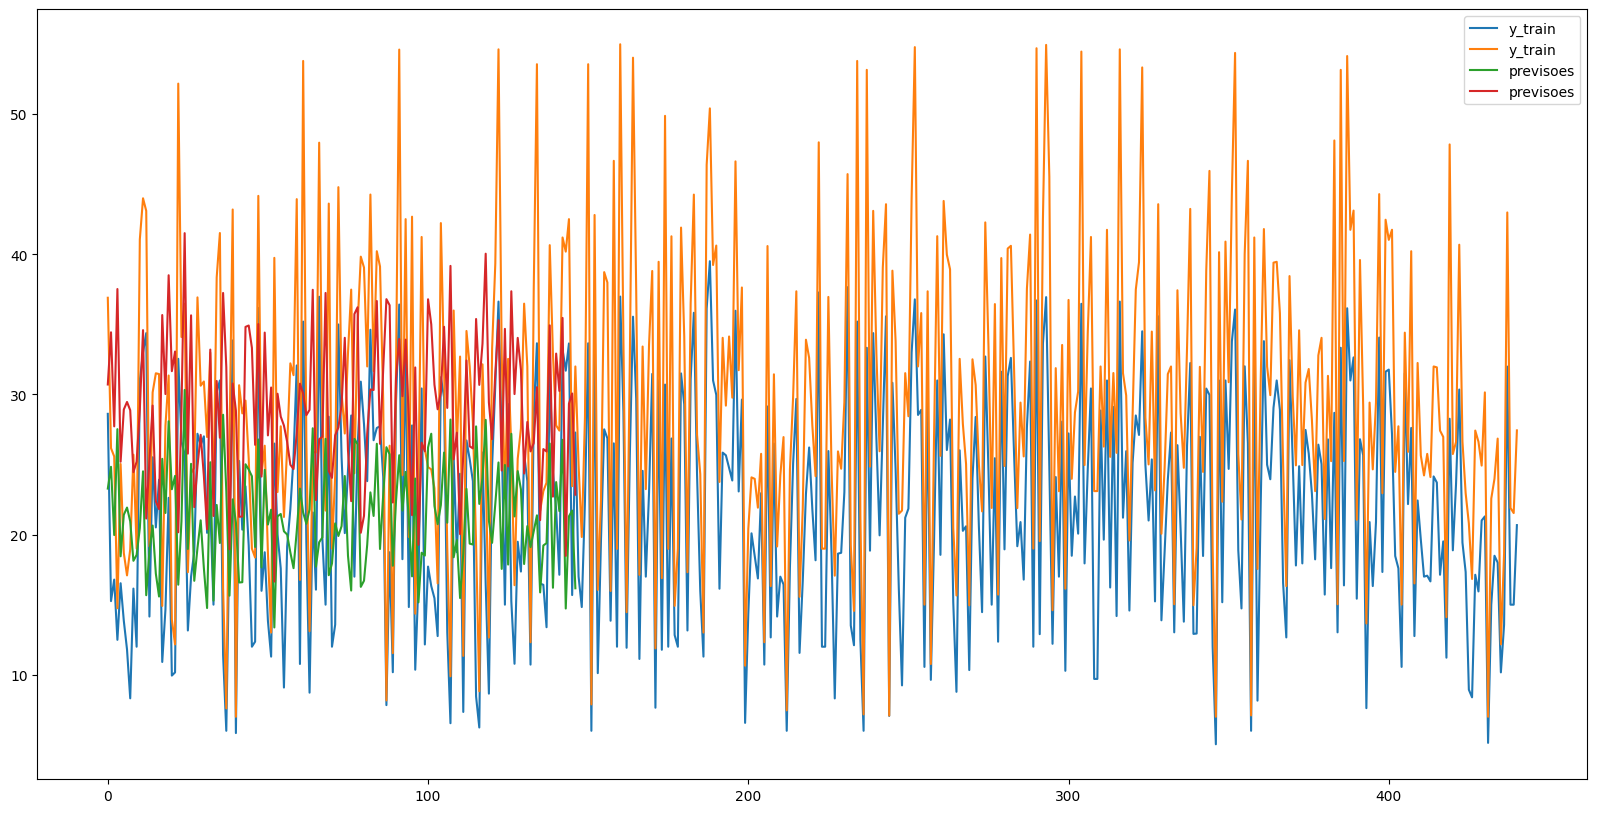

In [148]:
plt.figure(figsize=(20, 10))
plt.plot(y_train[::10], label="y_train")
plt.plot(previsoes[::10], label="previsoes")
plt.legend()

# Desempenho ruim. Isso é evidenciado pela distância entre as linhas

In [149]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [150]:
mean_absolute_error(y_test, previsoes)

6.735558011055398

In [152]:
np.sqrt(mean_squared_error(y_test, previsoes))

np.float64(8.232330380386033)

In [154]:
abs(y_test - previsoes).mean()

np.float64(6.735558011055399)